In [16]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [17]:
X_test = pd.read_csv("../dataset/X_test.csv")
y_test = pd.read_csv("../dataset/y_test.csv")

y_test = y_test.values.ravel()

In [18]:
lr = joblib.load("../models/linear_regression.pkl")
dt = joblib.load("../models/decision_tree.pkl")
rf = joblib.load("../models/random_forest.pkl")
knn = joblib.load("../models/knn.pkl")
scaler = joblib.load("../models/scaler.pkl")

In [19]:
X_test_scaled = scaler.transform(X_test)

In [20]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

In [21]:
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [22]:
lr_m = metrics(y_test, y_pred_lr)
dt_m = metrics(y_test, y_pred_dt)
rf_m = metrics(y_test, y_pred_rf)
knn_m = metrics(y_test, y_pred_knn)

In [23]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "KNN"],
    "MAE": [lr_m[0], dt_m[0], rf_m[0], knn_m[0]],
    "MSE": [lr_m[1], dt_m[1], rf_m[1], knn_m[1]],
    "RMSE": [lr_m[2], dt_m[2], rf_m[2], knn_m[2]],
    "R2 Score": [lr_m[3], dt_m[3], rf_m[3], knn_m[3]]
})

print(results)

               Model           MAE           MSE          RMSE  R2 Score
0  Linear Regression  12404.616189  2.548509e+08  15964.048905  0.865143
1      Decision Tree  13000.000000  4.057692e+08  20143.714423  0.785283
2      Random Forest  10337.384615  2.256604e+08  15021.997096  0.880590
3                KNN  41092.307692  2.368938e+09  48671.741920 -0.253548


In [24]:
print(results.sort_values(by="R2 Score", ascending=False))

               Model           MAE           MSE          RMSE  R2 Score
2      Random Forest  10337.384615  2.256604e+08  15021.997096  0.880590
0  Linear Regression  12404.616189  2.548509e+08  15964.048905  0.865143
1      Decision Tree  13000.000000  4.057692e+08  20143.714423  0.785283
3                KNN  41092.307692  2.368938e+09  48671.741920 -0.253548


In [25]:
results["Accuracy %"] = results["R2 Score"] * 100

In [26]:
print(results[["Model", "Accuracy %"]])

               Model  Accuracy %
0  Linear Regression   86.514308
1      Decision Tree   78.528309
2      Random Forest   88.058951
3                KNN  -25.354788


In [27]:
for i in range(len(results)):
    print(
        f"{results.loc[i, 'Model']} → "
        f"Accuracy: {results.loc[i, 'R2 Score']*100:.2f}%"
    )

Linear Regression → Accuracy: 86.51%
Decision Tree → Accuracy: 78.53%
Random Forest → Accuracy: 88.06%
KNN → Accuracy: -25.35%


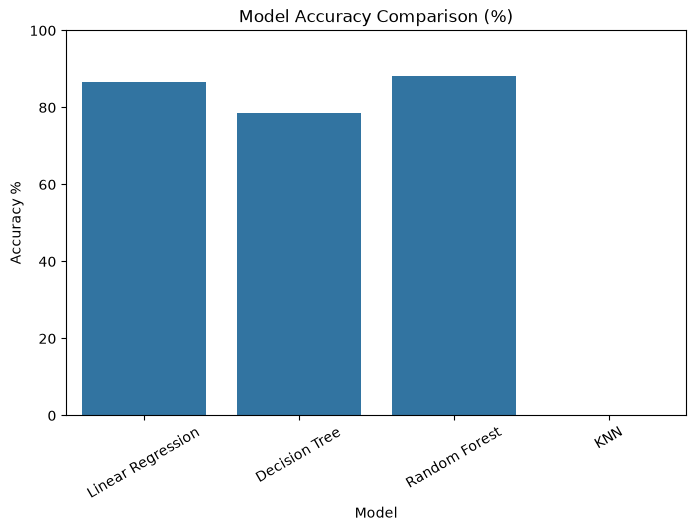

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy %"
)

plt.title("Model Accuracy Comparison (%)")
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.show()